In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import keras
from keras.datasets import mnist
from matplotlib import pyplot as plt
import numpy as np

In [27]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [28]:
# El método shape no devuelve la forma del conjunto. 60.000 imágenes de 28x28
print("Shape: ", x_train.shape)

Shape:  (60000, 28, 28)


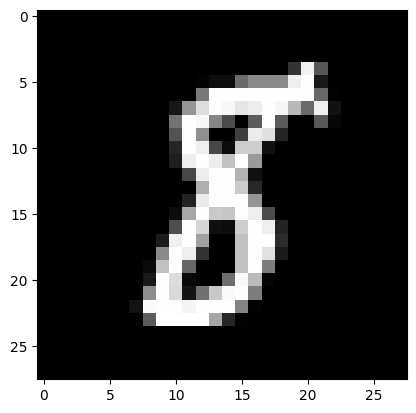

In [29]:
# Visualizar una image, por ejemplo la que tiene índice 125

image= np.array(x_train[125], dtype='float')
plt.imshow(image, cmap='gray')
plt.show()

In [30]:
print("Label: ", y_train[125])

Label:  8


In [31]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255 # Escalar a un rango entre 0 y 1
x_test /= 255


In [32]:
print("Max value: ", max(x_train[125].reshape(784)))
print("Min value: ", min(x_train[125].reshape(784)))

Max value:  1.0
Min value:  0.0


In [33]:
# Preparar las etiquetas transformándolas a fomato one_hot.
y_train = keras.utils.to_categorical(y_train, 10) # 10 clases
y_test = keras.utils.to_categorical(y_test, 10)

print("Label: ", y_train[125])

Label:  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


# Preparación del modelo 1.
Usando CNN sin usar capas avanzadas

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [38]:
# El parámetro validation_split, hace la partición de validación que le ponemos en el momento

history = model.fit(x_train, y_train, epochs=12, batch_size=32, validation_split=0.1)

Epoch 1/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8816 - loss: 0.3749 - val_accuracy: 0.9862 - val_loss: 0.0499
Epoch 2/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0633 - val_accuracy: 0.9897 - val_loss: 0.0352
Epoch 3/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9902 - val_loss: 0.0310
Epoch 4/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9880 - loss: 0.0368 - val_accuracy: 0.9893 - val_loss: 0.0377
Epoch 5/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.9888 - val_loss: 0.0418
Epoch 6/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9912 - loss: 0.0254 - val_accuracy: 0.9913 - val_loss: 0.0339
Epoch 7/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9928 - loss: 0.0213 - val_accuracy: 0.9912 - val_loss: 0.0309
Epoch 8/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0197 -

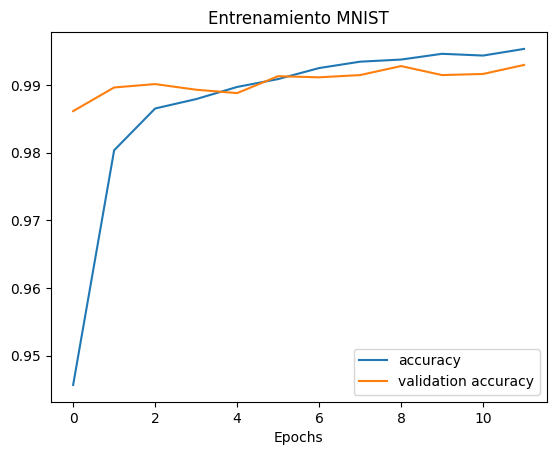

In [39]:
from matplotlib import pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title('Entrenamiento MNIST')
plt.xlabel('Epochs')
plt.legend(loc="lower right")

In [40]:
print(model.metrics_names)
model.evaluate(x_test, y_test, verbose=1)

['loss', 'compile_metrics']
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0344


[0.026521185413002968, 0.992900013923645]

In [ ]:
model.save("")